### 6. DECISION TREES AND ENSENBLE LEARNING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv('data/CreditScoring.csv', sep=',')

In [2]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head(3).T

,0,1,2
status,1,1,2
seniority,9,17,10
home,1,1,2
time,60,60,36
age,30,58,46
marital,2,3,2
records,1,1,2
job,3,1,3
expenses,73,48,90
income,129,131,200


#### RE-ENCODING THE CATEGORICAL VARIABLES

To handle the categorical variables, we need to address a few important considerations. The R file in the repository provides insights into preprocessing this data.

Here are the key points:

1. Categorical Variable Information: The R file also offers information about the categorical variables. For example:

- ‘Status’ is encoded as ‘good’ (1) and ‘bad’ (2).
- ‘Home’ includes categories like ‘rent,’ ‘owner,’ ‘priv,’ ‘ignore,’ ‘parents,’ and ‘other.’
- ‘Marital’ encompasses ‘single,’ ‘married,’ ‘widow,’ ‘separated,’ and ‘divorced.’
- ‘Records’ has ‘yes’ and ‘no.’
- ‘Job’ includes ‘fixed,’ ‘partime,’ ‘freelance,’ and ‘other.’

2. Missing Values: The missing values are encoded as a series of nines (99999999). We’ll need to address how to handle these missing values.


To proceed, we’ll need to translate these numerical values back into their respective categorical strings. This ensures our data is more interpretable and ready for analysis.

In [3]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df['status'] = df['status'].map(status_values)
df['home'] = df['home'].map(home_values)
df['marital'] = df['marital'].map(marital_values)
df['records'] = df['records'].map(records_values)
df['job'] = df['job'].map(job_values)

In [4]:
df.describe().round().T
# 99999999.0 is a placeholder for missing values in the dataset.
# We will replace it with NaN for better handling of missing data.

,count,mean,std,min,25%,50%,75%,max
seniority,4455.0,8.0,8.0,0.0,2.0,5.0,12.0,48.0
time,4455.0,46.0,15.0,6.0,36.0,48.0,60.0,72.0
age,4455.0,37.0,11.0,18.0,28.0,36.0,45.0,68.0
expenses,4455.0,56.0,20.0,35.0,35.0,51.0,72.0,180.0
income,4455.0,763317.0,8703625.0,0.0,80.0,120.0,166.0,99999999.0
assets,4455.0,1060341.0,10217569.0,0.0,0.0,3500.0,6000.0,99999999.0
debt,4455.0,404382.0,6344253.0,0.0,0.0,0.0,0.0,99999999.0
amount,4455.0,1039.0,475.0,100.0,700.0,1000.0,1300.0,5000.0
price,4455.0,1463.0,628.0,105.0,1118.0,1400.0,1692.0,11140.0


In [5]:
# handling with missing values
replace_values = ['income', 'assets', 'debt']

for col in replace_values:
    df[col] = df[col].replace(99999999.0, np.nan)

# handling with unknown values
# only one row has 'unk' in the 'status' column,
# so we can safely remove it from the dataset.
df = df[df['status'] != 'unk'].reset_index(drop=True)

#### PERFORMING THE DATA SPLIT

In [6]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

df_full_train.reset_index(drop=True)
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

y_full_train = (df_full_train['status'] == 'default').astype(int).values
y_train = (df_train['status'] == 'default').astype(int).values
y_val = (df_val['status'] == 'default').astype(int).values
y_test = (df_test['status'] == 'default').astype(int).values

X_full_train = df_full_train.drop(columns=['status'])
X_train = df_train.drop(columns=['status'])
X_val = df_val.drop(columns=['status'])
X_test = df_test.drop(columns=['status'])



#### DECISION TREES

Decision trees are a fundamental machine learning technique used for both classification and regression tasks. Their structure mirrors a flowchart: each internal node represents a feature, each branch a decision rule, and each leaf node a final prediction.

What makes decision trees stand out is their interpretability - unlike many ML models, the logic behind a prediction can be read and understood by humans, making them especially useful when explainability matters.

#### HOW A DECISION TREE IS STRUCTURED

A decision tree is made up of nodes connected by branches. Each node tests a condition on a feature - the result is either true (right branch) or false (left branch). This continues recursively until the tree reaches a leaf node, which holds the final prediction: OK or DEFAULT.

Each path from root to leaf represents a decision rule the model has learned from training data. The deeper the tree, the more specific the rules - though very deep trees risk overfitting.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

# ## Now we need to turn our training dataframe into a list of dictionaries
# ## then turn this list of dictionaries into the feature matrix. After that we train the model.

train_dict = X_train.fillna(0).to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

val_dict = X_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)

In [8]:
visualize = pd.DataFrame(X_train, columns=dv.get_feature_names_out().tolist())
visualize.head()

,age,amount,assets,debt,expenses,home=ignore,home=other,home=owner,home=parents,home=private,...,marital=married,marital=separated,marital=single,marital=unk,marital=widow,price,records=no,records=yes,seniority,time
0,36.0,1000.0,10000.0,0.0,75.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1400.0,1.0,0.0,10.0,36.0
1,32.0,1100.0,0.0,0.0,35.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1330.0,0.0,1.0,6.0,48.0
2,40.0,1320.0,0.0,0.0,75.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1600.0,1.0,0.0,1.0,48.0
3,23.0,1078.0,0.0,0.0,35.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1079.0,1.0,0.0,1.0,48.0
4,46.0,1100.0,4000.0,0.0,60.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1897.0,1.0,0.0,5.0,36.0


In [9]:
max_depth = [2, 3, 4, 5, 10, None]

for max_depth in max_depth:
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=11)
    tree.fit(X_train, y_train)

    # Validação
    y_pred_val = tree.predict_proba(X_val)[:, 1]
    print(f'max_depth: {max_depth}, ROC_AUC val:   {roc_auc_score(y_val, y_pred_val) * 100:.3f}%')

    # Treino (para checar overfitting)
    y_pred_train = tree.predict_proba(X_train)[:, 1]
    print(f'max_depth: {max_depth}, ROC_AUC train: {roc_auc_score(y_train, y_pred_train) * 100:.3f}%')

    print('---')

max_depth: 2, ROC_AUC val:   66.853%
max_depth: 2, ROC_AUC train: 70.550%
---
max_depth: 3, ROC_AUC val:   73.891%
max_depth: 3, ROC_AUC train: 77.610%
---
max_depth: 4, ROC_AUC val:   76.128%
max_depth: 4, ROC_AUC train: 81.643%
---
max_depth: 5, ROC_AUC val:   76.650%
max_depth: 5, ROC_AUC train: 84.338%
---
max_depth: 10, ROC_AUC val:   69.037%
max_depth: 10, ROC_AUC train: 96.385%
---
max_depth: None, ROC_AUC val:   66.386%
max_depth: None, ROC_AUC train: 100.000%
---


#### OVERFITTING

Looking at the validation results alone, `max_depth=5` gives the best AUC score of `76.650%` - but compare it with the training score of `84.338%`. That gap is a **warning sign**.

When we let the tree grow freely (max_depth=None), the validation AUC drops to `66.386%` while the training AUC hits a perfect `100%`. This is a textbook case of **overfitting**: the model simply memorizes every single training example, including its noise, and creates rules so specific that they are useless for any new, unseen data. It fails to generalize.

The deeper the tree, the more specific the rules - and the wider the gap between train and validation performance:

| max_depth  | ROC-AUC VAL | ROC-AUC TRAIN |    GAP     |
|:----------:|:-----------:|:-------------:|:----------:|
|      2     |    66.853%  |    70.550%    |    3.7pp   |
|      3     |    73.891%  |    77.610%    |    3.7pp   |
|      4     |    76.128%  |    81.643%    |    5.5pp   |
|      5     |    76.650%  |    84.338%    |    7.7pp   |
|     10     |    69.037%  |    96.385%    |   27.3pp   |
|    None    |    66.386%  |   100.000%    |   33.6pp   |

**By restricting the tree depth, we force it to learn broader**, `more generalizable` rules. `max_depth=5` strikes the best balance here, but it's worth tuning further - for instance by also controlling min_samples_leaf - to reduce that train/val gap without sacrificing too much validation performance.

#### DECISION STUMP

A **Decision Stump** is a decision tree with a depth of exactly 1 - meaning it makes a single split based on one feature and immediately produces a prediction. It's the most minimal form a decision tree can take: one question, two answers, done.

Despite its simplicity, the stump is far from useless. It's a foundational building block in ensemble methods like AdaBoost, where many weak learners (stumps) are combined to form a strong classifier.

---

#### FROM A STUMP TO A REAL TREE

To understand a stump, it helps to contrast it with a deeper tree. Consider the credit risk model below, trained with **`max_depth=3`** :

In [10]:
from sklearn.tree import export_text

tree = DecisionTreeClassifier(max_depth=3, random_state=11)
tree.fit(X_train, y_train)
# y_pred = tree.predict_proba(X_val)[:, 1]

feature_names = dv.get_feature_names_out().tolist()
print(export_text(tree, feature_names=feature_names))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0



**The root node asks: `"Does this person have no negative records?"`** - that's exactly what a stump would be. It splits the entire dataset into two groups based on that single feature and stops there.

But at max_**`depth=3`**, the tree goes further. Each branch refines the prediction using additional features like seniority, income, amount, and assets. **The model now captures interactions** - for example, a person with no negative records is still considered risky if their seniority is low and their requested amount is high.

|   Depth       | Name           | Behavior                           |
|---------------|----------------|------------------------------------|
|     1         | Decision Stump | One split, very high bias          |
|    2–5        | Shallow tree   | Captures some interactions         |
| Unconstrained | Full tree      | Low bias, high variance (overfits) |

#### DECISION TREE LEARNING ALGORITHM

#### KEY CONCEPTS

- **Decision Stump**: a decision tree with only one level (one condition node + leaves).
- **Split**: a condition of the form `FEATURE > T`, separating records into `LEFT` (False) and `RIGHT` (True).
- **Leaf / Decision Node**: the endpoint where we assign the most frequent class label.
- **Impurity**: how mixed a leaf is. Lower impurity = better split.
- **Misclassification Rate**: fraction of wrongly predicted records in a group = one way to measure impurity.

In [11]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df = pd.DataFrame(data, columns=['assets', 'status'])
df.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


#### FINDING THE BEST THRESHOLD 'T'

For each candidate threshold `T`, we split the dataset:
- `LEFT`  > `assets <= T`
- `RIGHT` > `assets > T`

Then we measure the **misclassification rate** on each side and compute the average.

In [12]:
def misclassification_rate(series):
    """
    Calculate the misclassification rate of a group of labels.

    This measures how "impure" a node is: if we always predict the majority
    class for every record in this group, what fraction would we get wrong?

    Example:
        Group = [default, default, default, ok]
        Majority class = 'default' (75%)
        Misclassification rate = 1 - 0.75 = 0.25 (25% error)

    Parameters
    ----------
    series : pd.Series
        A Series containing class labels (e.g. 'ok', 'default').

    Returns
    -------
    float
        Fraction of records that would be misclassified (0.0 = pure group).
    """
    # Edge case: empty group has no error
    if len(series) == 0:
        return 0.0

    # Get the proportion of each class label (e.g. default: 0.75, ok: 0.25)
    counts = series.value_counts(normalize=True)

    # The majority class is the first entry (value_counts sorts descending).
    # Error = everything that is NOT the majority class.
    return 1 - counts.iloc[0]


# Candidate thresholds 
# These are the unique asset values we'll test as split points.
# We skip the min (0) and max (9000) since they would leave one side empty.
Ts = [0, 2000, 3000, 4000, 5000, 8000]

results = []  # Will hold one dict of metrics per threshold

# Evaluate every threshold
for T in Ts:

    # Split the dataset into two groups based on the threshold:
    #   LEFT  > records where assets <= T  (condition is FALSE: "not > T")
    #   RIGHT > records where assets >  T  (condition is TRUE)
    left  = df[df.assets <= T]['status']
    right = df[df.assets >  T]['status']

    # Measure how impure (mixed) each group is
    imp_left  = misclassification_rate(left)
    imp_right = misclassification_rate(right)

    n = len(df)  # Total number of records in the dataset

    # Weighted average impurity:
    # Groups of different sizes should contribute proportionally.
    # A large pure group is better than a small pure group.
    avg = (len(left) * imp_left + len(right) * imp_right) / n

    # Store results for this threshold
    results.append({
        'T': T,

        # At each leaf, the tree makes a prediction by looking at all the training
        # records that landed in that group and picking the most common class label.
        # This is called the "majority vote" rule.
        #
        # pd.Series.mode() returns all values that appear most frequently.
        # We take [0] to get a single label even if there's a tie.
        #
        # Example - LEFT group for T=4000:
        #   assets  status
        #   2000    default   ← default
        #   0       default   ← default
        #   4000    ok        ← ok
        #   3000    default   ← default
        #
        #   mode() → ['default']   (appears 3 out of 4 times)
        #   Decision LEFT = 'default'
        #
        # If the group happens to be empty (e.g. T=0 produces an empty LEFT),
        # we fall back to '-' to avoid an IndexError on mode()[0].
        'Decision LEFT':  left.mode()[0]  if len(left)  else '-',
        'Decision RIGHT': right.mode()[0] if len(right) else '-',

        # Impurity formatted as a percentage for readability
        'Impurity LEFT':  f"{imp_left:.0%}",
        'Impurity RIGHT': f"{imp_right:.0%}",

        # The metric we minimise to find the best split
        'AVG Impurity':   f"{avg:.0%}",
    })

# Display results
# The row with the lowest AVG Impurity is the best threshold to use.
pd.DataFrame(results).set_index('T')

,Decision LEFT,Decision RIGHT,Impurity LEFT,Impurity RIGHT,AVG Impurity
T,,,,,
0,default,ok,0%,43%,38%
2000,default,ok,0%,33%,25%
3000,default,ok,0%,20%,12%
4000,default,ok,25%,25%,25%
5000,default,default,50%,50%,50%
8000,default,ok,43%,0%,38%


#### RESULT

The threshold **T = 3000** gives the lowest average impurity (**12%**), so it is the best split.

```
ASSETS > 3000
   /        \
FALSE       TRUE
DEFAULT      OK
```

#### SUMMARY: HOW THE ALGORITHM WORKS

1. Sort the dataset by the feature.
2. Identify all candidate thresholds (unique values).
3. For each threshold, split into LEFT and RIGHT.
4. Compute impurity (e.g. misclassification rate) for each side.
5. Compute weighted average impurity.
6. Pick the threshold with the **lowest** average impurity.

---

**Other impurity criteria** (available in scikit-learn): `gini`, `entropy`. Same idea, different formula.

#### DECISION TREES PARAMETER TUNING

Let’s take a closer look at the parameters available for the DecisionTreeClassifier. For a more comprehensive list of parameters, you can refer to the official website. Some of the key parameters include:

- **criterion**: This parameter determines the impurity measure used for splitting. You can choose between ‘gini’ for Gini impurity and ‘entropy’ for information gain. The choice of criterion can significantly impact the quality of the splits in the decision tree.
- **max_depth**: This parameter controls the maximum depth of the decision tree. It plays a crucial role in preventing overfitting by limiting the complexity of the tree. Selecting an appropriate value for max_depth helps strike a balance between model simplicity and complexity.
- **min_samples_leaf**: This parameter specifies the minimum number of samples required in a leaf node. It influences the granularity of the splits. Smaller values can result in finer splits and a more complex tree, while larger values lead to coarser splits and a simpler tree.


In [13]:
md = [4, 5, 6, 7, 10, 15, 20, None]
msl = [1, 2, 5, 10, 15, 20, 100, 200, 500]
scores = []

for max_depth in md:
    for samples_leaf in msl:
        tree = DecisionTreeClassifier(max_depth=max_depth,
                                      min_samples_leaf=samples_leaf)

        tree.fit(X_train, y_train)

        y_pred = tree.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred) * 100
        
        scores.append((max_depth, samples_leaf, auc))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores = df_scores.sort_values('auc', ascending=False).reset_index(drop=True)

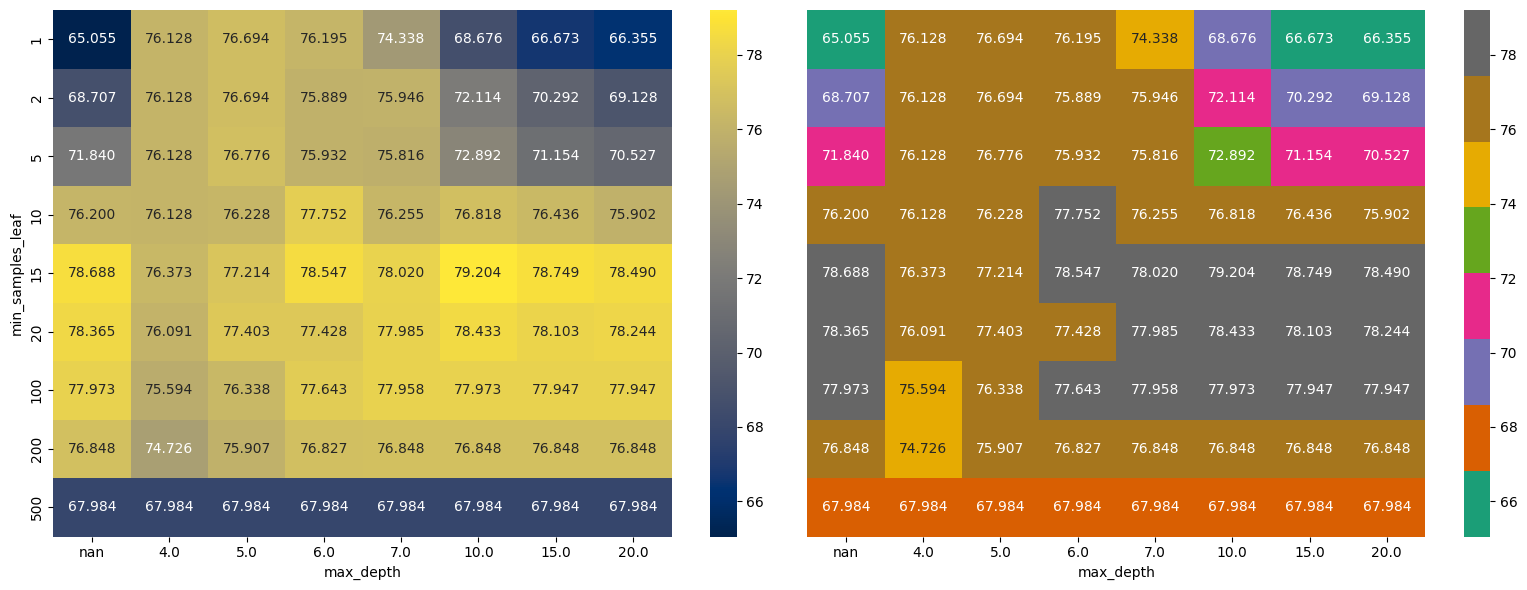

In [14]:
scores_pivot = df_scores.pivot(index='min_samples_leaf',
                columns='max_depth',
                values='auc').round(3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ax=axes[0],
            data=scores_pivot,
            annot=True,
            fmt='.3f', 
            cmap='cividis')

sns.heatmap(
    ax=axes[1],
    data=scores_pivot,
    annot=True,
    fmt='.3f',
    cmap='Dark2')

axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].tick_params(left=False)

plt.tight_layout()
plt.show()

In this heatmap, the **`lightest regions indicate the highest scores`**, while the darker areas represent lower-performing parameter combinations. Although the absolute best value can be identified visually, relying exclusively on a single peak **is not** always the most reliable strategy, since nearby parameter combinations may produce very similar results with lower model complexity.

By analyzing the second heatmap, it is possible to observe a concentration of stronger performance for max_depth values between 5 and 20, combined with min_samples_leaf values roughly between 15 and 100. This suggests that the model tends to generalize better when the tree is not excessively shallow, while still maintaining a moderate number of samples in the leaf nodes.

It is also possible to notice that some of the highest scores appear when max_depth is greater than 10. However, **the improvement obtained in these deeper trees is relatively small** and often residual when compared to simpler configurations. In practical terms, **increasing tree depth adds complexity and reduces interpretability**, while providing only marginal gains in performance.

For this reason, when multiple parameter combinations produce very similar results, the preferable approach is usually to select the less complex model. In this scenario, choosing a smaller max_depth is advantageous because it creates a simpler and more interpretable decision tree, while still maintaining competitive predictive performance.

Additionally, this type of grid search does not guarantee that the global optimum has been found. There may still be unexplored parameter values capable of producing slightly better results. For smaller datasets, testing a wider range of combinations is feasible, but for larger datasets, the search space must often be constrained for computational efficiency. **A common strategy is to first identify a reasonable range for max_depth and then fine-tune secondary parameters such as min_samples_leaf.**

In [15]:
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
tree.fit(X_train, y_train)

y_pred_dt = tree.predict_proba(X_val)[:, 1]
score_dt = roc_auc_score(y_val, y_pred_dt)
print(f'ROC_AUC (Decision Tree): {score_dt:.3%}')

ROC_AUC (Decision Tree): 78.547%


#### ENSEMBLES AND RANDOM FOREST

#### Key Concepts

- **Ensemble / Board of experts**: instead of one model, we train several and aggregate their predictions (e.g. average probability). The collective is more reliable than any single model.
- **Random Forest**: an ensemble of decision trees where randomness is introduced in two ways:
  - Each tree sees a **random subset of features** - trees disagree and complement each other.
  - Each tree is trained on a **bootstrapped sample** of rows - further diversity.
- **Final prediction**: average of all trees' predicted probabilities > `(1/n) * Σ(pi)`.
- Without randomness, all trees would be identical and the ensemble would add nothing.

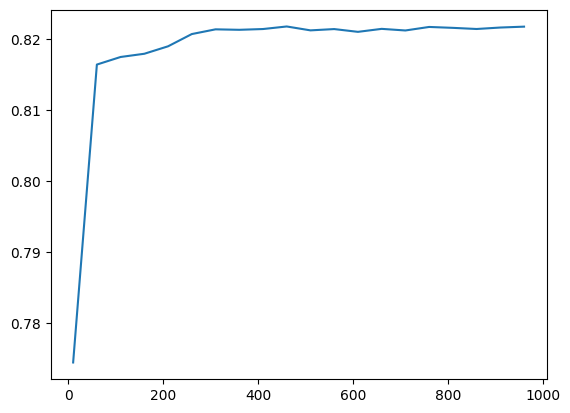

In [16]:
from sklearn.ensemble import RandomForestClassifier

scores = []
 
for n in range(10, 1001, 50):
    rf = RandomForestClassifier(n_estimators=n,
                                random_state=1,
                                n_jobs=-1)
    rf.fit(X_train, y_train)
 
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
     
    scores.append((n, auc))
 
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

plt.plot(df_scores.n_estimators, df_scores.auc)

We observe that **the model’s performance improves as the number of estimators increases up to approximately 50 trees**. Beyond this point, however, the performance curve begins to stabilize, indicating a **plateau effect**. In other words, adding more trees does not produce meaningful improvements in predictive performance. Therefore, using more than 50 estimators does not seem to provide a substantial benefit, while it does increase computational cost and training time.

Next, we proceed to the **hyperparameter tuning stage** of the random forest model. Since a random forest is fundamentally an ensemble of decision trees, many of the key parameters remain the same as those used for tuning individual decision trees. In this case, our primary focus is on the max_depth and min_samples_leaf parameters.

We begin by analyzing the max_depth parameter, training multiple random forest models with different depth values to evaluate how tree complexity affects the model’s overall performance. The goal is to identify a balance between predictive accuracy and model simplicity, avoiding unnecessarily deep trees that may increase complexity without delivering significant gains.

#### Tuning `max_depth`

A Random Forest is a collection of decision trees, so tree-level parameters matter too.  
`max_depth` controls how deep each individual tree can grow:
- Too shallow > underfitting (tree can't capture patterns).
- Too deep > overfitting (tree memorises noise).

We test depths `[5, 10, 15]` while varying `n_estimators`.

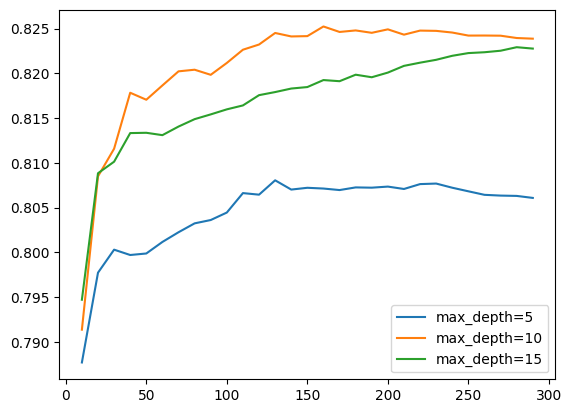

In [17]:
scores = []
 
max_depth_list = [5, 10, 15]

for d in max_depth_list:
    for n in range(10, 300, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    n_jobs=-1,
                                    random_state=1)
        rf.fit(X_train, y_train)
 
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
 
        scores.append((d, n, auc))
 
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

for d in max_depth_list:
    df_subset = df_scores[df_scores.max_depth == d]
     
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)
 
plt.legend()

In the plot, we can observe that the AUC scores for max_depth values of 10 and 15 are initially very similar. However, after a certain number of estimators, the performance of max_depth = 15 begins to plateau, showing only marginal improvements as additional trees are added. In contrast, the configuration with max_depth = 10 continues to improve more consistently, reaching its best performance at approximately 125 estimators.

**This behavior highlights the importance of properly tuning the max_depth parameter**. While deeper trees may appear promising at first, they do not necessarily lead to better generalization. In this case, **`max_depth = 10` provides a noticeably better balance between performance and complexity** when compared with both max_depth = 15 and max_depth = 5. Therefore, selecting max_depth = 10 is a well-supported decision, since its performance advantage is sufficiently significant while avoiding the unnecessary complexity associated with deeper trees.

In [18]:
from IPython.display import clear_output


n_estimators_list = [10, 20, 50, 100, 200]
max_depth_list = [5, 10, 15]
min_samples_leaf_list = [1, 3, 5, 10, 50]

scores = []
best_params_rf = []
best_auc_rf = 0
model_count = 1

number_of_models = len(n_estimators_list) * len(max_depth_list) * len(min_samples_leaf_list)
print(f'Training {number_of_models} models...')

for msl in min_samples_leaf_list:
    for md in max_depth_list:
        for nest in n_estimators_list:

            clear_output(wait=True)

            print('TRAINING MODEL...')
            print(f'[ {(model_count / number_of_models):.2%} >> {model_count} // {number_of_models} ]')
            print()
            print(f'n_estimators: {nest}')
            print(f'max_depth: {md}')
            print(f'min_samples_leaf: {msl}')
            print()

            rforest = RandomForestClassifier(n_estimators=nest,
                                             max_depth=md,
                                             min_samples_leaf=msl,
                                             n_jobs=-1,
                                             random_state=1)
            rforest.fit(X_train, y_train)

            y_pred = rforest.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred) * 100
            
            scores.append((nest, md, msl, auc))
            model_count += 1

            if auc > best_auc_rf:
                best_auc_rf = auc
                best_params_rf = [nest, md, msl]


df_scores = pd.DataFrame(scores, columns=['n_estimators', 'max_depth', 'min_samples_leaf', 'auc'])
df_scores = df_scores.sort_values('auc', ascending=False).reset_index(drop=True)

print('BEST PARAMETERS')
print(f'n_estimators: {best_params_rf[0]}')
print(f'max_depth: {best_params_rf[1]}')
print(f'min_samples_leaf: {best_params_rf[2]}')
print(f'best_auc: {best_auc_rf:.2f}%')
df_scores.round(3)

TRAINING MODEL...
[ 100.00% >> 75 // 75 ]

n_estimators: 200
max_depth: 15
min_samples_leaf: 50

BEST PARAMETERS
n_estimators: 200
max_depth: 15
min_samples_leaf: 3
best_auc: 82.86%


,n_estimators,max_depth,min_samples_leaf,auc
0,200,15,3,82.862
1,100,15,3,82.694
2,50,15,3,82.563
3,200,10,5,82.538
4,200,15,5,82.494
...,...,...,...,...
70,10,5,3,79.629
71,10,15,1,79.470
72,10,10,1,79.136
73,10,5,50,79.111


#### FINAL MODEL WITH TUNES PARAMETERS

In [19]:
n_estimators = best_params_rf[0]       # 200
max_depth = best_params_rf[1]          # 15
min_samples_leaf = best_params_rf[2]   # 3

rforest_final = RandomForestClassifier(n_estimators=n_estimators,
                                       max_depth=max_depth,
                                       min_samples_leaf=min_samples_leaf,
                                       n_jobs=-1,
                                       random_state=1)

rforest_final.fit(X_train, y_train)
y_pred = rforest_final.predict_proba(X_val)[:, 1]
score_rf = roc_auc_score(y_val, y_pred)
print(f'ROC_AUC (Random Forest): {score_rf:.3%}')

ROC_AUC (Random Forest): 82.862%


#### GRADIENT BOOSTING AND XGBOOST

#### 1 – Gradient Boosting vs. Random Forest

Both methods, Random Forest and Gradient Boosting, combine multiple decision trees into a single, stronger model - but they do it in very different ways.

**Random Forest: parallel, independent trees**

All trees are trained **at the same time**, each on a random subset of features and rows.
They know nothing about each other. The final prediction is the **average** of all trees:

$$\hat{y} = \frac{1}{n} \sum_{i=1}^{n} p_i$$

**Gradient Boosting: sequential, error-correcting trees**

Trees are trained **one after another**. Each new tree focuses specifically on the mistakes made by the previous trees - it is trained on the **residual errors**, not on the original labels.

The process works like this:
1. Train **model 1** on the original data > it makes some errors.
2. Train **model 2** to predict the errors of model 1 > it corrects some of them, but also introduces new ones.
3. Train **model 3** to predict the remaining errors of model 2 > and so on.
4. The final prediction is the **sum** of all individual model outputs.

Each tree is small (a 'weak learner'), but the chain of corrections gradually builds a **strong learner**.

**Key difference**

|                     | Random Forest           | Gradient Boosting       |
|---------------------|-------------------------|-------------------------|
| Training order      | Parallel                | Sequential              |
| Each tree trains on | Random subset of data   | Errors of previous tree |
| Combination         | Average                 | Weighted sum            |
| Speed               | Faster (parallelizable) | Slower (sequential)     |
| Overfitting risk    | Lower                   | Higher (needs careful tuning) |

#### HANDLING WITH XGBOOST

**XGBoost** (e**X**treme **G**radient **Boost**ing) is a highly optimised library for gradient boosting. It is widely used in competitions and production systems because of its speed and performance.

It has its own internal data format called **DMatrix**, which is a compressed binary format optimised for fast training. We need to convert our Pandas/NumPy arrays into DMatrix before training.

In [20]:
import xgboost as xgb

# Convert the train/validation sets into XGBoost's optimised DMatrix format.
# label= tells XGBoost which column is the target variable.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

DMatrix is XGBoost’s optimized internal data structure, designed for faster training and lower memory usage, especially with large or sparse datasets. When using the native XGBoost API (xgb.train, xgb.cv), data is typically converted manually into a DMatrix object to take advantage of these optimizations and advanced training features. However, when using the Scikit-Learn API (XGBClassifier, XGBRegressor), this conversion is handled automatically internally, so manually creating a DMatrix is usually unnecessary. In practice, explicit DMatrix usage is more common in advanced or performance-oriented workflows, while the Scikit-Learn interface is preferred for simpler and more standard machine learning pipelines.

#### XGBOOST PARAMETERS EXPLAINED

Before training, we define a dictionary of parameters. Here is what each one does:

| Parameter | Role | Analogy |
|---|---|---|
| `eta` | **Learning rate** - how much each new tree contributes to the final prediction. Low values make learning slower but more stable. | Step size when walking downhill |
| `max_depth` | Maximum depth of each individual tree. Deeper = more complex, higher overfitting risk. | Same as in Decision Tree / Random Forest |
| `min_child_weight` | Minimum sum of sample weights in a leaf. Acts as a regulariser - prevents the tree from creating very small, noisy leaves. | Similar to `min_samples_leaf` in scikit-learn |
| `objective` | Defines the **loss function** to minimise. `binary:logistic` outputs a probability for binary classification tasks. | The metric the model is trying to get right |
| `nthread` | Number of CPU threads to use during training. Speeds up the process. | Same idea as `n_jobs=-1` in scikit-learn |
| `seed` | Fixes the random seed for reproducibility. Same seed = same model every run. | Same as `random_state` in scikit-learn |
| `verbosity` | Controls how much XGBoost prints during training. `0`=silent, `1`=warnings, `2`=info, `3`=debug. | Log level |

**`num_boost_round`** is not inside the params dict - it is passed directly to `xgb.train()` and controls how many trees (boosting rounds) are built in total.

In [21]:
xgb_params = {
    'eta': 0.3,               # learning rate - how fast the model adapts
    'max_depth': 6,           # each tree can be at most 6 levels deep
    'min_child_weight': 1,    # minimum records required in a leaf (no restriction here)

    'objective': 'binary:logistic',  # output a probability for binary classification
    'nthread': 8,             # use 8 CPU threads for faster training

    'seed': 1,                # reproducibility
    'verbosity': 0,           # show warnings only
}

# num_boost_round = number of sequential trees to build
# Start small (10) - often comparable to 200 rounds without the extra cost
xgboost = xgb.train(xgb_params, dtrain, num_boost_round=10)

y_pred = xgboost.predict(dval)
auc = roc_auc_score(y_val, y_pred)
print(f'ROC-AUC score: {auc:.2%}')

ROC-AUC score: 81.19%


#### SUMMARY

**Gradient Boosting** trains trees one at a time, each correcting the errors of the previous. This gives it a natural advantage over a single decision tree and often outperforms a Random Forest when properly tuned.

**XGBoost** is an efficient implementation of this idea. With default settings and only 10 trees, it already achieves ~81.19% AUC.

**Watch out for overfitting**
Because each tree corrects the previous one, XGBoost can **memorise the training data** if:
- `num_boost_round` is too large
- `eta` is too high (aggressive learning)
- `max_depth` is too deep

Parameter tuning is essential to unlock XGBoost's full potential safely.

#### XGBOOST PARAMETER TUNING

In [22]:
xgb_grid = {
    'eta': [0.01, 0.05, 0.1, 0.3, 1.0],
    'max_depth': [3, 4, 6, 10],
    'min_child_weight': [1, 10, 30],
    'colsample_bytree': [0.4, 0.7, 1.0],
}

# xgb_grid = {
#     'eta': [0.1],
#     'max_depth': [3],
#     'min_child_weight': [30],
# }


df_scores = []
best_auc_xgb = 0
best_params_xgb = None
model_count = 1
number_of_models = len(xgb_grid['eta']) * len(xgb_grid['max_depth']) * len(xgb_grid['min_child_weight']) * len(xgb_grid['colsample_bytree'])
print(f'Training {number_of_models} models...')

for eta in xgb_grid['eta']:
    for max_depth in xgb_grid['max_depth']:
        for min_child_weight in xgb_grid['min_child_weight']:
            for colsample_bytree in xgb_grid['colsample_bytree']:

                xgb_params = {
                    'eta': eta,
                    'max_depth': max_depth,
                    'min_child_weight': min_child_weight,
                    'colsample_bytree': colsample_bytree,

                    'objective': 'binary:logistic',
                    'eval_metric': 'auc',

                    'nthread': 8,
                    'seed': 1,
                    'verbosity': 0,
                }

                xgboost = xgb.train(xgb_params,
                                    dtrain,
                                    num_boost_round=175)

                y_pred = xgboost.predict(dval)
                auc = roc_auc_score(y_val, y_pred) * 100

                clear_output(wait=True)

                print('TRAINING MODEL...')
                print(f'[ {(model_count / number_of_models):.2%} >> {model_count} // {number_of_models} ]')
                print()
                print(f'eta: {eta}')
                print(f'max_depth: {max_depth}')
                print(f'min_child_weight: {min_child_weight}')
                print(f'colsample_bytree: {colsample_bytree}')
                print(f'ROC-AUC score: {auc:.2f}%')
                print()

                df_scores.append((eta, max_depth, min_child_weight, colsample_bytree, auc))

                if auc > best_auc_xgb:
                    best_auc_xgb = auc
                    best_params_xgb = (eta, max_depth, min_child_weight, colsample_bytree)

                model_count += 1

df_scores = pd.DataFrame(df_scores, columns=['eta', 'max_depth', 'min_child_weight', 'colsample_bytree', 'auc'])
df_scores = df_scores.sort_values('auc', ascending=False).reset_index(drop=True)

print('BEST PARAMETERS')
print(f'eta: {best_params_xgb[0]}')
print(f'max_depth: {best_params_xgb[1]}')
print(f'min_child_weight: {best_params_xgb[2]}')
print(f'colsample_bytree: {best_params_xgb[3]}')
print(f'best_auc: {best_auc_xgb:.3f}%')
df_scores.round(3)

TRAINING MODEL...
[ 100.00% >> 180 // 180 ]

eta: 1.0
max_depth: 10
min_child_weight: 30
colsample_bytree: 1.0
ROC-AUC score: 79.59%

BEST PARAMETERS
eta: 0.05
max_depth: 6
min_child_weight: 10
colsample_bytree: 0.7
best_auc: 83.717%


,eta,max_depth,min_child_weight,colsample_bytree,auc
0,0.05,6,10,0.7,83.717
1,0.05,4,10,0.7,83.662
2,0.05,3,1,0.7,83.581
3,0.05,4,30,1.0,83.560
4,0.05,10,30,1.0,83.538
...,...,...,...,...,...
175,1.00,3,1,0.7,78.037
176,1.00,6,10,0.7,77.954
177,1.00,10,1,0.4,77.522
178,1.00,6,10,0.4,77.409


#### FINAL MODEL WITH TUNES PARAMETERS

In [23]:
best_params = {'eta': best_params_xgb[0],
               'max_depth': best_params_xgb[1],
               'min_child_weight': best_params_xgb[2],
               'colsample_bytree': best_params_xgb[3],
               
                'objective': 'binary:logistic',
                'eval_metric': 'auc',

                'nthread': 8,
                'seed': 1,
                'verbosity': 0}

xgboost_final = xgb.train(best_params,
                          dtrain,                          
                          num_boost_round=175)

y_pred = xgboost_final.predict(dval)
score_xgb = roc_auc_score(y_val, y_pred)
print(f'ROC_AUC (XGBoost): {score_xgb:.3%}')

ROC_AUC (XGBoost): 83.717%


Two hyperparameters that are especially useful in XGBoost are **`colsample_bytree`** and **`subsample`**. **Both introduce randomness into the training process**, helping reduce overfitting and improve the model’s ability to generalize.

- **`colsample_bytree`**: This parameter is conceptually similar to the feature sampling strategy used in Random Forests. **It controls the proportion of features (columns) that each tree can access during training**. Its **values range from 0 to 1, where 1.0 means that all features are used**. Lower values, such as 0.3 or 0.6, force the model to work with different subsets of features, increasing diversity among the trees and often improving robustness. A common approach is to start with broader values and then fine-tune around the most promising range.

- **`subsample`**: While colsample_bytree samples columns, **subsample samples rows from the training dataset**. For example, setting **subsample = 0.5 means that each boosting iteration uses a random 50% subset of the training observations**. This randomness can help prevent the model from memorizing the training data and reduce overfitting, especially in larger datasets.

Together, these parameters act as regularization techniques by introducing controlled randomness into the boosting process. Proper tuning can significantly improve model stability and generalization performance.

Beyond these parameters, XGBoost offers many additional hyperparameters and tuning strategies. There are also several practical “rules of thumb” commonly discussed in the machine learning community. Platforms such as Kaggle provide extensive tutorials, notebooks, and discussions that can be very helpful for understanding effective approaches to XGBoost hyperparameter tuning in real-world scenarios.

#### SELECTING THE FINAL MODEL

In [24]:
print('BEST MODEL SELECTION')
print(f'ROC_AUC - Decision Tree: {score_dt:.3%}')
print(f'ROC_AUC - Random Forest: {score_rf:.3%}')
print(f'ROC_AUC - XGBoost: {score_xgb:.3%}')

BEST MODEL SELECTION
ROC_AUC - Decision Tree: 78.547%
ROC_AUC - Random Forest: 82.862%
ROC_AUC - XGBoost: 83.717%


In [25]:
# DICT VECTORIZER
dv = DictVectorizer(sparse=False)

dicts_full_train = X_full_train.fillna(0).to_dict(orient='records')
dicts_test = X_test.fillna(0).to_dict(orient='records')

X_full_train = dv.fit_transform(dicts_full_train)
X_test = dv.transform(dicts_test)

feature_names = dv.get_feature_names_out().tolist()

# DMATRIX
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=feature_names)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

In [26]:
# TRAINING THE FINAL MODEL
xgb_selected_params = {'eta': best_params_xgb[0],
                       'max_depth': best_params_xgb[1],
                       'min_child_weight': best_params_xgb[2],
                       'colsample_bytree': best_params_xgb[3],

                       'objective': 'binary:logistic',
                       'eval_metric': 'auc',

                       'nthread': 8,
                       # 'seed': 1,
                       'verbosity': 0}

xgb_final = xgb.train(xgb_selected_params, dfulltrain, num_boost_round=175)

# PREDICTING AND EVALUATING THE FINAL MODEL
y_pred = xgb_final.predict(dtest)
score_xgb_final = roc_auc_score(y_test, y_pred)
print('FINAL MODEL EVALUATION')
print(f'ROC_AUC test dataset (XGBoost): {score_xgb_final:.3%}')

FINAL MODEL EVALUATION
ROC_AUC test dataset (XGBoost): 82.890%
